# SVM baseline scaling and expanded parameter search

This notebook runs three controlled comparisons of the original RBF SVM workflow.
It is reconstructed from supplied code and recorded-output exports, rather than
being the original author's untouched notebook.

## What the names mean

- **A / Experiment 1:** unscaled SVM with the original 20 parameter combinations.
- **B / Experiment 2:** StandardScaler plus SVM with those same 20 combinations.
- **C / Experiment 3:** the scaled pipeline with 49 parameter combinations.
- **SVM parameter `C`:** the penalty for training errors. It is different from the experiment label C.
- **`gamma`:** how locally the RBF kernel responds to a training observation.
  `gamma='scale'` chooses a kernel parameter; it does not standardize the input features.

All three searches share one 2,000-row sample, 1,400 training rows, 600 development
rows and the same 50 CV folds. Selection uses mean CV **ordinary accuracy**.
Balanced accuracy, recall, F1 and error counts describe the selected predictions.
The baseline-to-scaled comparison includes **scaling with parameter reselection**.

## Run in Jupyter or Anaconda

1. Use Python 3.11 with the packages in `requirements.txt`. Set `DATASET_PATH` to the original uncompressed CSV.
2. Read [input requirements](../docs/INPUTS.md). If protecting an existing reserve, set its membership manifest in `PROTECTED_RESERVE_PATH`.
3. Start a fresh kernel and run the code cells in order. The CSV is read in chunks.
4. `RUN_TUNING=True` is already enabled. A baseline mismatch stops the expanded search until investigated.
5. Save the executed notebook and the evidence ZIP. Do not bypass a failed check.

## What has been simplified

Short expressions are kept together. `train_indices`, `evaluation_indices` and
`evidence_dir` replace abbreviated names. The fitting, sampling, parameter order,
scoring and evidence checks remain the same. The checks document whether the
comparison is valid; they are not extra model improvements.

**Recorded output** cells preserve the earlier user runs and figures. Code cells
start unexecuted. This edition was checked without training, opening the dataset
or loading supplied models. New runs can have different timings, IDs and file
hashes. These are development results, with no untouched final-test score.


In [ ]:
# Imports, paths, fixed settings, and evidence helpers.

from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import json
import platform
import sys
import uuid
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import binomtest
import sklearn
import joblib
from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    make_scorer
)

DATASET_PATH = Path("../data/data_4.csv")  # EDIT THIS ONE PATH if necessary.
NOTEBOOK_PATH = Path("SVM_Enhancement_Controlled_Experiments.ipynb")
OUTPUT_ROOT = Path("svm_enhancement_evidence")
CHUNK_ROWS = 200_000
N_JOBS = 2  # Resource-only difference from source n_jobs=-1.
SOURCE_SEED = 42
SAMPLE_SIZE = 2000
EVALUATION_FRACTION = 0.30
N_FOLDS = 50  # Kept fixed for source comparison; changing folds is a separate experiment.
HASH_DATASET = True  # Extra sequential read of the CSV; records exact file identity.
PROTECTED_RESERVE_PATH = None  # Optional Path to CSV with csv_row_id and optionally Flow_ID; never model features/labels.

SOURCE_URL = "https://github.com/DuseTrive/Anomaly-Based-NID-using-svm/blob/main/Suport%20Vector%20Machine%20book.ipynb"
REFERENCE = {
    "ordinary_accuracy": 0.9683333333333334,
    "balanced_accuracy": 0.9679951690821256,
    "confusion_matrix": [[315, 9], [10, 266]]
}
LABEL_MAP = {"Benign": 0, "DDoS attacks-LOIC-HTTP": 1}
META_NAMES = ["Flow_ID", "Src_IP", "Dst_IP", "Timestamp"]

dataset_initial_stat = DATASET_PATH.stat() if DATASET_PATH.is_file() else None
assert DATASET_PATH.is_file(), f"Set DATASET_PATH to your uncompressed original CSV: {DATASET_PATH}"
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
evidence_dir = OUTPUT_ROOT / run_id
evidence_dir.mkdir(parents=True, exist_ok=False)


# Save the current evidence record as readable JSON.
def save_json(name, value):
    (evidence_dir / name).write_text(
        json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False),
        encoding="utf-8"
    )


# Read a file in small blocks and calculate its identity checksum.
def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

environment = {
    "python": sys.version,
    "executable": sys.executable,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "scipy": scipy.__version__,
    "joblib": joblib.__version__,
    "run_id": run_id,
    "source_url": SOURCE_URL,
    "dataset_path": str(DATASET_PATH.resolve()),
    "dataset_bytes": DATASET_PATH.stat().st_size,
    "n_jobs": N_JOBS,
    "evaluation_role": "previously examined development set, not final test"
}
save_json("environment.json", environment)
print("Evidence folder:", evidence_dir.resolve())
print("Python:", platform.python_version(), "| sklearn:", sklearn.__version__, "| pandas:", pd.__version__)


**Recorded output from the supplied run — not rerun here**

    Evidence folder: [local folder]/20261004T102021Z_45a6d3fc
    Python: 3.11.17 | sklearn: 1.9.1 | pandas: 3.0.6
    



## 1. Freeze the source sample without loading the whole CSV into RAM
The loader retains the source's port 80/443 filter, removal of any feature with missing/infinite values in the filtered population, benign downsampling, attack-first concatenation, two seeded shuffles and first 2,000 rows.

It scans feature validity and row identities first, then loads the selected rows. This is a memory-saving reimplementation of source row selection, not a new sampling strategy. Header spaces are replaced by underscores as in the source. Numeric CSV fields are read as float64, which is also the source's final model input type.

**Inherited limitation:** deciding which columns to drop from the full filtered population happens before splitting. This is retained to isolate scaling and parameter effects; it is not described as fully leakage-free preprocessing. An improved train-only feature-retention protocol would require another controlled experiment.




In [ ]:
# First CSV pass: audit columns and reproduce the original sample selection.


# Keep the source convention: replace spaces in column names.
def normalize_name(name):
    return str(name).replace(" ", "_")

header = list(pd.read_csv(DATASET_PATH, nrows=0).columns)
normalized = [normalize_name(c) for c in header]
assert len(set(normalized)) == len(normalized), "Ambiguous column names after normalization."
assert {"Dst_Port", "Label", *META_NAMES}.issubset(normalized), "Wrong dataset schema."
numeric_columns = [c for c, n in zip(header, normalized) if n not in META_NAMES + ["Label"]]
dtypes = {c: np.float64 for c in numeric_columns}
dtypes.update({c: "string" for c, n in zip(header, normalized) if n in META_NAMES + ["Label"]})

row_id_parts, label_parts = [], []
invalid_counts = np.zeros(len(numeric_columns), dtype=np.int64)
raw_rows, filtered_rows = 0, 0
scan_start = perf_counter()
for chunk_number, chunk in enumerate(pd.read_csv(DATASET_PATH, dtype=dtypes, chunksize=CHUNK_ROWS), 1):
    chunk.columns = [normalize_name(c) for c in chunk.columns]
    keep = chunk["Dst_Port"].isin([80, 443]).to_numpy()
    filtered = chunk.loc[keep]
    mapped = filtered["Label"].map(LABEL_MAP)
    assert mapped.notna().all(), "Unexpected or missing label: inspect before modelling."
    values = filtered[[normalize_name(c) for c in numeric_columns]].to_numpy(dtype=np.float64)
    invalid_counts += (~np.isfinite(values)).sum(axis=0)
    row_id_parts.append(np.flatnonzero(keep).astype(np.int64) + raw_rows)
    label_parts.append(mapped.to_numpy(dtype=np.int8))
    raw_rows += len(chunk)
    filtered_rows += len(filtered)
    if chunk_number % 10 == 0:
        print(f"First pass: {raw_rows:,} CSV rows scanned; {filtered_rows:,} port-filtered rows.")

filtered_row_ids = np.concatenate(row_id_parts)
filtered_labels = np.concatenate(label_parts)
del row_id_parts, label_parts, chunk, filtered, values
feature_names = [normalize_name(c) for c, count in zip(numeric_columns, invalid_counts) if count == 0]
dropped_features = {normalize_name(c): int(count) for c, count in zip(
    numeric_columns,
    invalid_counts
) if count > 0}
assert len(feature_names) == 77, (
    f"Expected 77 source features, got {len(feature_names)}. Inspect dataset and missing-value policy."
)
assert set(np.unique(filtered_labels)) == {0, 1}
attack_positions = np.flatnonzero(filtered_labels == 1)
benign_positions = np.flatnonzero(filtered_labels == 0)
assert len(benign_positions) >= len(attack_positions) > 0
# Sampling a Series of row positions uses the same pandas permutation as the source's DataFrame.
sampled_benign = pd.Series(benign_positions).sample(
    n=len(attack_positions),
    random_state=SOURCE_SEED
).to_numpy()
balanced_positions = pd.Series(np.concatenate([attack_positions, sampled_benign]))
first_shuffle = balanced_positions.sample(frac=1, random_state=SOURCE_SEED)
second_shuffle = first_shuffle.sample(frac=1, random_state=SOURCE_SEED).reset_index(drop=True)
sample_positions = second_shuffle.iloc[:SAMPLE_SIZE].to_numpy()
selected_row_ids = filtered_row_ids[sample_positions]
expected_y = filtered_labels[sample_positions].astype(np.float64)
assert len(selected_row_ids) == SAMPLE_SIZE and len(np.unique(selected_row_ids)) == SAMPLE_SIZE

dataset_audit = {
    "raw_rows": int(raw_rows),
    "filtered_rows": int(filtered_rows),
    "filtered_class_counts": {"benign": int(len(benign_positions)), "attack": int(len(attack_positions))},
    "balanced_pool_rows": int(len(balanced_positions)),
    "sample_rows": SAMPLE_SIZE,
    "feature_names": feature_names,
    "dropped_nonfinite_features": dropped_features,
    "sampling_seed": SOURCE_SEED,
    "csv_scan_seconds": perf_counter() - scan_start,
    "loader": "two-pass float64 chunk reader; source-equivalent row-position sampling",
    "feature_removal_scope": "full port-filtered population, inherited source limitation"
}
save_json("dataset_audit.json", dataset_audit)
print("Rows:", raw_rows, "| Port-filtered:", filtered_rows, "| Features:", len(feature_names))
print("Removed features:", dropped_features)
print("Selected class counts:", pd.Series(expected_y).value_counts().sort_index().to_dict())


**Recorded output from the supplied run — not rerun here**

    First pass: 2,000,000 CSV rows scanned; 1,049,869 port-filtered rows.
    First pass: 4,000,000 CSV rows scanned; 1,590,370 port-filtered rows.
    First pass: 6,000,000 CSV rows scanned; 2,097,596 port-filtered rows.
    First pass: 7,948,748 CSV rows scanned; 2,665,877 port-filtered rows.
    Rows: 7948748 | Port-filtered: 2665877 | Features: 77
    Removed features: {'Flow_Byts/s': 779, 'Flow_Pkts/s': 779}
    Selected class counts: {0.0: 1003, 1.0: 997}
    




In [ ]:
# Second CSV pass: load only the selected feature rows.

selected_parts = []
offset = 0
wanted = set(int(v) for v in selected_row_ids)
read_columns = [c for c in header if normalize_name(c) in feature_names + META_NAMES + ["Label"]]
read_dtypes = {c: dtypes[c] for c in read_columns}
second_start = perf_counter()
for chunk_number, chunk in enumerate(
    pd.read_csv(DATASET_PATH, usecols=read_columns, dtype=read_dtypes, chunksize=CHUNK_ROWS),
    1
):
    ids = np.arange(offset, offset + len(chunk), dtype=np.int64)
    mask = np.isin(ids, selected_row_ids)
    if mask.any():
        part = chunk.loc[mask].copy()
        part.columns = [normalize_name(c) for c in part.columns]
        part.index = ids[mask]
        selected_parts.append(part)
    offset += len(chunk)
assert offset == raw_rows, "CSV row count changed between passes."
selected = pd.concat(selected_parts).loc[selected_row_ids].copy()
assert selected.index.is_unique and len(selected) == SAMPLE_SIZE
assert selected[META_NAMES].notna().all().all(), "Missing audit metadata: inspect first."
X = selected[feature_names].to_numpy(dtype=np.float64)
y = selected["Label"].map(LABEL_MAP).to_numpy(dtype=np.float64)
metadata = selected[META_NAMES].reset_index(drop=True)
metadata.insert(0, "csv_row_id", selected_row_ids)
np.testing.assert_array_equal(y, expected_y)
assert X.shape == (2000, 77) and np.isfinite(X).all()
dataset_audit["second_scan_seconds"] = perf_counter() - second_start
assert DATASET_PATH.stat().st_size == dataset_initial_stat.st_size and DATASET_PATH.stat().st_mtime_ns == dataset_initial_stat.st_mtime_ns, "CSV was modified during loading."
dataset_audit["dataset_sha256"] = sha256_file(DATASET_PATH) if HASH_DATASET else None
save_json("dataset_audit.json", dataset_audit)
del selected_parts, chunk, selected, filtered_row_ids, filtered_labels
print("Frozen sample:", X.shape)
print("Dataset SHA256:", dataset_audit["dataset_sha256"] or "not computed")


**Recorded output from the supplied run — not rerun here**

    Frozen sample: (2000, 77)
    Dataset SHA256: 7287a4d7740a1dddbf330ceb2beb6a4889d33ba63674558a68b5eb50d16711df
    



## 2. Freeze the outer split and all CV folds
This retains the source's 70/30 split with seed 42 and **no outer stratification**, and its classifier default of 50-fold stratified CV without shuffle.

Folds are materialised once and reused in A/B/C. Each has 28 validation rows in the 1,400-row training set. Many small folds can produce unstable per-fold estimates and substantial cost; 50 folds are retained for comparability, not claimed to be the best general choice.

Flow ID and exact-feature overlap are checked without changing the split. Shared Flow IDs are a warning about related observations; they are not automatically proof of leakage. Exact duplicate features deserve further investigation. This notebook measures the source protocol first; group-aware splitting is a separate next experiment.




In [ ]:
# Freeze the shared split, CV folds, and overlap checks.

train_indices, evaluation_indices = train_test_split(
    np.arange(SAMPLE_SIZE), test_size=EVALUATION_FRACTION, random_state=SOURCE_SEED
)
X_train_raw, X_eval_raw = X[train_indices].copy(), X[evaluation_indices].copy()
y_train, y_eval = y[train_indices].copy(), y[evaluation_indices].copy()
assert len(train_indices) == 1400 and len(evaluation_indices) == 600
assert not set(train_indices).intersection(evaluation_indices)
cv_folds = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=False).split(X_train_raw, y_train))
assert len(cv_folds) == 50
validation_seen = np.zeros(len(train_indices), dtype=int)
fold_rows = []
train_flows = metadata.iloc[train_indices]["Flow_ID"].astype(str).to_numpy()
eval_flows = metadata.iloc[evaluation_indices]["Flow_ID"].astype(str).to_numpy()
for fold, (fold_train_indices, fold_validation_indices) in enumerate(cv_folds):
    assert not set(fold_train_indices).intersection(fold_validation_indices)
    assert len(fold_train_indices) + len(fold_validation_indices) == len(train_indices)
    assert set(np.unique(y_train[fold_train_indices])) == {0, 1}
    assert set(np.unique(y_train[fold_validation_indices])) == {0, 1}
    validation_seen[fold_validation_indices] += 1
    fold_rows.append({
        "fold": fold,
        "fit_rows": len(fold_train_indices),
        "validation_rows": len(fold_validation_indices),
        "shared_flow_ids": len(set(train_flows[fold_train_indices]).intersection(train_flows[fold_validation_indices]))
    })
np.testing.assert_array_equal(validation_seen, np.ones(len(train_indices), dtype=int))


# Identify exact feature rows for the original split audit.
def feature_hashes(values):
    return [hashlib.sha256(np.asarray(row, dtype="<f8").tobytes()).hexdigest() for row in values]

train_feature_hashes = set(feature_hashes(X_train_raw))
eval_feature_hashes = feature_hashes(X_eval_raw)
overlap_audit = {
    "outer_shared_flow_ids": len(set(train_flows).intersection(eval_flows)),
    "outer_evaluation_rows_with_training_feature_match": sum(h in train_feature_hashes for h in eval_feature_hashes),
    "cv_folds_with_shared_flow_ids": sum(r["shared_flow_ids"] > 0 for r in fold_rows),
    "interpretation": "Source-protocol diagnostic; no automatic claim of independent traffic generalisation."
}
save_json("overlap_audit.json", overlap_audit)
pd.DataFrame(fold_rows).to_csv(evidence_dir / "fold_audit.csv", index=False)
split_membership = metadata.copy()
split_membership["label"] = y.astype(int)
split_membership["role"] = "development_evaluation"
split_membership.loc[train_indices, "role"] = "training"
split_membership.to_csv(evidence_dir / "split_membership.csv", index=False)
np.savez_compressed(
    evidence_dir / "frozen_inputs.npz",
    X_train=X_train_raw,
    y_train=y_train,
    X_eval=X_eval_raw,
    y_eval=y_eval,
    train_pos=train_indices,
    eval_pos=evaluation_indices
)
np.savez_compressed(evidence_dir / "cv_folds.npz", **{
    f"{kind}_{i}": ids for i, pair in enumerate(cv_folds)
    for kind, ids in zip(["fit", "validation"], pair)
})
print("Training counts:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Evaluation counts:", pd.Series(y_eval).value_counts().sort_index().to_dict())
print("Overlap audit:", overlap_audit)
if any(overlap_audit[k] for k in [
    "outer_shared_flow_ids",
    "outer_evaluation_rows_with_training_feature_match",
    "cv_folds_with_shared_flow_ids"
]):
    warnings.warn("Related/duplicate observations detected. Report this limitation and propose a separate group-aware evaluation.")

reserve_guard = {"manifest_supplied": PROTECTED_RESERVE_PATH is not None, "exposure_verified": False}
if PROTECTED_RESERVE_PATH is not None:
    reserve_manifest = pd.read_csv(Path(PROTECTED_RESERVE_PATH))
    assert "csv_row_id" in reserve_manifest.columns, "Reserve manifest needs csv_row_id."
    shared_ids = set(selected_row_ids.astype(int)).intersection(reserve_manifest["csv_row_id"].astype(int))
    shared_groups = set()
    if "Flow_ID" in reserve_manifest.columns:
        shared_groups = set(metadata["Flow_ID"].astype(str)).intersection(reserve_manifest["Flow_ID"].dropna().astype(str))
    reserve_guard.update({"shared_rows": len(shared_ids), "shared_groups": len(shared_groups)})
    save_json("reserve_guard.json", reserve_guard)
    assert not shared_ids and not shared_groups, (
        "Source sample overlaps the protected reserve. Stop before training. "
        "Exact source reproduction and reserve protection require a separately reviewed protocol."
    )
    reserve_guard["exposure_verified"] = True
    reserve_guard["scope"] = "selected sample row/group exclusion only; full-population feature-dropping remains inherited"
else:
    warnings.warn("No protected-reserve manifest supplied: existing reserve row/group exposure is unverified. No separate final-test scoring is performed.")
save_json("reserve_guard.json", reserve_guard)


**Recorded output from the supplied run — not rerun here**

    Training counts: {0.0: 679, 1.0: 721}
    Evaluation counts: {0.0: 324, 1.0: 276}
    Overlap audit: {'outer_shared_flow_ids': 1, 'outer_evaluation_rows_with_training_feature_match': 0, 'cv_folds_with_shared_flow_ids': 6, 'interpretation': 'Source-protocol diagnostic; no automatic claim of independent traffic generalisation.'}
    

    [local kernel file]:54: UserWarning: Related/duplicate observations detected. Report this limitation and propose a separate group-aware evaluation.
      warnings.warn("Related/duplicate observations detected. Report this limitation and propose a separate group-aware evaluation.")
    [local kernel file]:73: UserWarning: No protected-reserve manifest supplied: existing reserve row/group exposure is unverified. No separate final-test scoring is performed.
      warnings.warn("No protected-reserve manifest supplied: existing reserve row/group exposure is unverified. No separate final-test scoring is performed.")
    



## 3. Measurement and selection rules
All searches select **highest mean CV ordinary accuracy**, retaining the source criterion. Balanced accuracy and attack F1/precision/recall are collected for every candidate, along with training scores. Candidates are never chosen by their 600-row evaluation score.

For a binary task, balanced accuracy is the mean of benign recall and attack recall. Missed attacks are false negatives; false alarms are false positives, with label 1 defined as attack. Ordinary accuracy weights classes according to the evaluation sample's prevalence. Downsampling makes that prevalence unlike the full CSV.

We record both training-set performance and CV training/validation means. Low training and validation performance suggests underfitting; a large training–validation gap suggests overfitting. Neither can be diagnosed from a large C or gamma alone. Fold standard deviations are descriptive, not independent standard errors.




In [ ]:
# Define the original grid, scoring rules, and shared search function.

ORIGINAL_GRID = {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto", 0.1, 1, 10]}
SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "attack_f1": make_scorer(f1_score, pos_label=1, zero_division=0),
    "attack_precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "attack_recall": make_scorer(recall_score, pos_label=1, zero_division=0)
}
searches, metrics_rows, predictions, validation_checks = {}, [], {}, {}
input_digest = hashlib.sha256(X_train_raw.tobytes() + X_eval_raw.tobytes() + y_train.tobytes() + y_eval.tobytes()).hexdigest()


# Calculate every metric from the same predictions and decision scores.
def metric_values(actual, predicted, scores):
    tn, fp, fn, tp = [int(v) for v in confusion_matrix(actual, predicted, labels=[0, 1]).ravel()]
    ordinary = accuracy_score(actual, predicted)
    balanced = balanced_accuracy_score(actual, predicted)
    np.testing.assert_allclose(ordinary, (tn + tp) / len(actual))
    np.testing.assert_allclose(balanced, 0.5 * (tn / (tn + fp) + tp / (tp + fn)))
    return {
        "ordinary_accuracy": float(ordinary),
        "balanced_accuracy": float(balanced),
        "attack_precision": float(precision_score(actual, predicted, zero_division=0)),
        "attack_recall": float(recall_score(actual, predicted, zero_division=0)),
        "attack_f1": float(f1_score(actual, predicted, zero_division=0)),
        "benign_recall": tn / (tn + fp),
        "false_alarm_rate": fp / (tn + fp),
        "missed_attack_rate": fn / (tp + fn),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "errors": fp + fn,
        "roc_auc": float(roc_auc_score(actual, scores)),
        "average_precision": float(average_precision_score(actual, scores))
    }


# Save completed comparisons and their validation checks.
def export_progress():
    pd.DataFrame(metrics_rows).to_csv(evidence_dir / "comparison.csv", index=False)
    save_json("validation_checks.json", validation_checks)


# Search the fixed folds, evaluate the selected model, and save its evidence.
def run_search(name, estimator, grid):
    if name in searches:
        raise RuntimeError(f"{name} already ran. Use a fresh kernel for a fresh full experiment.")
    expected_cv_fits = len(ParameterGrid(grid)) * len(cv_folds)
    print(f"{name}: {len(ParameterGrid(grid))} candidates x {len(cv_folds)} folds = {expected_cv_fits} CV fits + 1 refit.")
    search = GridSearchCV(
        estimator,
        grid,
        cv=cv_folds,
        scoring=SCORING,
        refit="accuracy",
        return_train_score=True,
        n_jobs=N_JOBS,
        pre_dispatch=N_JOBS,
        verbose=1,
        error_score="raise"
    )
    started = perf_counter()
    search.fit(X_train_raw, y_train)
    search_seconds = perf_counter() - started
    searches[name] = search
    results = pd.DataFrame(search.cv_results_)
    assert np.isfinite(results["mean_test_accuracy"]).all()
    results.to_csv(evidence_dir / f"{name}_cv_results.csv", index=False)
    joblib.dump(search.best_estimator_, evidence_dir / f"{name}_selected_model.joblib")
    best_index = search.best_index_
    np.testing.assert_allclose(search.best_score_, results["mean_test_accuracy"].max())
    np.testing.assert_allclose(search.best_score_, results.iloc[best_index]["mean_test_accuracy"])
    selected_cv = results.iloc[best_index]
    record = {
        "model": name,
        "best_parameters": json.dumps(search.best_params_, sort_keys=True),
        "candidates": len(ParameterGrid(grid)),
        "cv_fits": expected_cv_fits,
        "search_and_refit_seconds": search_seconds,
        "refit_seconds": float(search.refit_time_),
        "support_vectors": (
            int(search.best_estimator_["svm"].n_support_.sum())
            if isinstance(search.best_estimator_, Pipeline)
            else int(search.best_estimator_.n_support_.sum())
        ),
        "selection_metric": "mean CV ordinary accuracy"
    }
    for metric in SCORING:
        for kind in ["mean_train", "mean_test", "std_test"]:
            record[f"cv_{kind}_{metric}"] = float(selected_cv[f"{kind}_{metric}"])
    for role, features, actual, positions in [
        ("training", X_train_raw, y_train, train_indices),
        ("development", X_eval_raw, y_eval, evaluation_indices)
    ]:
        started = perf_counter()
        predicted = search.predict(features)
        scores = search.decision_function(features)
        elapsed = perf_counter() - started
        values = metric_values(actual, predicted, scores)
        record.update({f"{role}_{k}": v for k, v in values.items()})
        record[f"{role}_prediction_and_score_seconds"] = elapsed
        rows = metadata.iloc[positions].reset_index(drop=True).copy()
        rows["actual"] = actual.astype(int)
        rows["predicted"] = predicted.astype(int)
        rows["decision_score"] = scores
        rows["correct"] = actual == predicted
        rows.to_csv(evidence_dir / f"{name}_{role}_predictions.csv", index=False)
        if role == "development":
            predictions[name] = predicted.copy()
        # Independently recompute from the written evidence.
        saved = pd.read_csv(evidence_dir / f"{name}_{role}_predictions.csv")
        recalculated = metric_values(saved["actual"], saved["predicted"], saved["decision_score"])
        for key in values:
            np.testing.assert_allclose(values[key], recalculated[key], rtol=1e-10, atol=1e-12)

    record["cv_train_validation_accuracy_gap"] = record["cv_mean_train_accuracy"] - record["cv_mean_test_accuracy"]
    current_digest = hashlib.sha256(X_train_raw.tobytes() + X_eval_raw.tobytes() + y_train.tobytes() + y_eval.tobytes()).hexdigest()
    assert current_digest == input_digest, "Inputs changed during fitting."
    assert search.cv is cv_folds and search.refit == "accuracy"
    validation_checks[name] = {
        "metric_recalculation_from_saved_predictions": True,
        "inputs_unchanged": True,
        "shared_materialized_cv_folds": True,
        "best_selected_by_cv_accuracy": True
    }
    if isinstance(search.best_estimator_, Pipeline):
        scaler = search.best_estimator_["scaler"]
        np.testing.assert_allclose(scaler.mean_, X_train_raw.mean(axis=0), rtol=1e-10, atol=1e-8)
        np.testing.assert_allclose(scaler.var_, X_train_raw.var(axis=0), rtol=1e-10, atol=1e-8)
        assert int(scaler.n_samples_seen_) == len(X_train_raw)
        fold_train_indices, fold_validation_indices = cv_folds[0]
        probe = clone(search.best_estimator_).fit(X_train_raw[fold_train_indices], y_train[fold_train_indices])
        np.testing.assert_allclose(
            probe["scaler"].mean_,
            X_train_raw[fold_train_indices].mean(axis=0),
            rtol=1e-10,
            atol=1e-8
        )
        assert int(probe["scaler"].n_samples_seen_) == len(fold_train_indices)
        validation_checks[name]["full_training_scaler_statistics_match"] = True
        validation_checks[name]["first_fold_scaler_statistics_match"] = True
        validation_checks[name]["extra_validation_probe_fits"] = 1
        pd.DataFrame({
            "feature": feature_names,
            "mean": scaler.mean_,
            "variance": scaler.var_,
            "scale": scaler.scale_
        }).to_csv(evidence_dir / f"{name}_scaler_statistics.csv", index=False)
    metrics_rows.append(record)
    export_progress()
    print("Selected:", search.best_params_)
    print(f"Development: ordinary={record['development_ordinary_accuracy']:.2%}, balanced={record['development_balanced_accuracy']:.2%}, missed={record['development_fn']}, false alarms={record['development_fp']}")
    print(f"CV accuracy={record['cv_mean_test_accuracy']:.2%}; CV train-validation gap={record['cv_train_validation_accuracy_gap']:.2%}")
    return search


## 4. A — original source model baseline
Core source behaviour is retained. Recording extra metrics, returning CV training scores, limiting workers to two and preserving row IDs are measurement/resource changes. The source's late, unused scaler and repeated evaluations of C on its test set are deliberately not replayed as model-selection steps.

If this reconstruction does not match your previously observed confusion matrix, inspect CSV identity, sample IDs, versions and notebook state before treating it as the same run.




In [ ]:
# Experiment 1 / A: train and measure the unscaled original-grid baseline.

baseline_search = run_search("A_original", SVC(), ORIGINAL_GRID)
baseline_row = metrics_rows[-1]
REFERENCE_MATCH = (
    [[baseline_row["development_tn"], baseline_row["development_fp"]],
     [baseline_row["development_fn"], baseline_row["development_tp"]]]
    == REFERENCE["confusion_matrix"]
)
validation_checks["reference_baseline"] = {
    "reference_confusion_matrix": REFERENCE["confusion_matrix"],
    "matched": bool(REFERENCE_MATCH),
    "interpretation": "A mismatch is a reproducibility issue to investigate, not permission to fabricate matching outputs."
}
export_progress()
print("Matches supplied baseline confusion matrix:", REFERENCE_MATCH)
if not REFERENCE_MATCH:
    warnings.warn("Baseline differs from your supplied run. Inspect data identity, sampling and versions before the C experiment.")


**Recorded output from the supplied run — not rerun here**

    A_original: 20 candidates x 50 folds = 1000 CV fits + 1 refit.
    Fitting 50 folds for each of 20 candidates, totalling 1000 fits
    Selected: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
    Development: ordinary=96.83%, balanced=96.80%, missed=10, false alarms=9
    CV accuracy=96.14%; CV train-validation gap=0.09%
    Matches supplied baseline confusion matrix: True
    



## 5. B — scaling with the original grid
StandardScaler centres features and divides by their training standard deviations. It is inside the pipeline, so CV validation rows and development rows do not fit the scaler.

**`gamma='scale'` does not standardise feature values.** It calculates a gamma from the model's input variance. Scaling can therefore change both the geometry and the numerical gamma chosen by that option. B measures that combined pipeline effect while retaining the same named grid.




In [ ]:
# Experiment 2 / B: add StandardScaler inside the pipeline; keep the original grid.

scaled_pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])
original_pipeline_grid = {f"svm__{key}": list(values) for key, values in ORIGINAL_GRID.items()}
scaled_search = run_search("B_scaled_original_grid", scaled_pipeline, original_pipeline_grid)
pd.DataFrame(metrics_rows)[[
    "model", "development_ordinary_accuracy", "development_balanced_accuracy",
    "development_attack_f1", "development_fn", "development_fp",
    "cv_mean_test_accuracy", "cv_mean_test_balanced_accuracy", "cv_train_validation_accuracy_gap"
]]


**Recorded output from the supplied run — not rerun here**

    B_scaled_original_grid: 20 candidates x 50 folds = 1000 CV fits + 1 refit.
    Fitting 50 folds for each of 20 candidates, totalling 1000 fits
    Selected: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
    Development: ordinary=99.83%, balanced=99.82%, missed=1, false alarms=0
    CV accuracy=99.64%; CV train-validation gap=0.14%
    




<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>development_ordinary_accuracy</th>
      <th>development_balanced_accuracy</th>
      <th>development_attack_f1</th>
      <th>development_fn</th>
      <th>development_fp</th>
      <th>cv_mean_test_accuracy</th>
      <th>cv_mean_test_balanced_accuracy</th>
      <th>cv_train_validation_accuracy_gap</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>A_original</td>
      <td>0.968333</td>
      <td>0.967995</td>
      <td>0.965517</td>
      <td>10</td>
      <td>9</td>
      <td>0.961429</td>
      <td>0.961165</td>
      <td>0.000889</td>
    </tr>
    <tr>
      <th>1</th>
      <td>B_scaled_original_grid</td>
      <td>0.998333</td>
      <td>0.998188</td>
      <td>0.998185</td>
      <td>1</td>
      <td>0</td>
      <td>0.996429</td>
      <td>0.996429</td>
      <td>0.001414</td>
    </tr>
  </tbody>
</table>
</div>





## 6. C — literature-informed parameter modification
The numerical values below are **our hypotheses**, not values copied from a paper, and do not guarantee improvement.

- **C = 0.01, 0.1, 1, 10, 100, 300, 1000.** Keep all original C values; add 0.01 as a stronger-regularisation diagnostic and 300/1000 above the previously selected boundary C=100. This tests whether the source stopped too early while exposing possible training–validation gaps.
- **Gamma = original five options plus g/3 and 3g**, where g is the numerical `'scale'` gamma calculated from standardised **training data only**. These two values probe around the training-scale reference. The original 0.1, 1 and 10 remain useful larger-gamma diagnostics.
- Select once by the same mean CV accuracy rule. Report balanced accuracy and error tradeoffs even if they deteriorate. Do not choose an alternative candidate after seeing the development set.

**Research support**
1. Ikram, S. T., & Cherukuri, A. K. (2016). *Improving Accuracy of Intrusion Detection Model Using PCA and optimized SVM*. Journal of Computing and Information Technology, 24(2), 133–148. [Publisher](https://hrcak.srce.hr/161730), [DOI](https://doi.org/10.20532/cit.2016.1002701). Supports investigating joint C–gamma optimisation in intrusion detection. Their PCA/dataset choices are not implemented here.
2. Wainer, J., & Fonseca, P. (2021). *How to tune the RBF SVM hyperparameters? An empirical evaluation of 18 search algorithms*. Artificial Intelligence Review, 54, 4771–4797. [DOI](https://doi.org/10.1007/s10462-021-10011-5). Supports treating search method and computing budget as experimental decisions. It does not establish that a larger grid always improves generalisation.
3. Wainer, J., & Cawley, G. (2017). *Empirical Evaluation of Resampling Procedures for Optimising SVM Hyperparameters*. Journal of Machine Learning Research, 18(15), 1–35. [Journal](https://jmlr.org/papers/v18/16-174.html). Shows resampling design matters for SVM tuning. Keeping 50 folds here isolates changes relative to the source; it is not a literature claim that 50 folds are necessary.
4. [Official scikit-learn RBF parameter example](https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html) supports joint range exploration and checking a winning search boundary; [pipeline guidance](https://scikit-learn.org/stable/common_pitfalls.html) supports fitting preprocessing on training data only.

Read the full papers for your individual critical literature review; these brief implementation links are not a completed review.




In [ ]:
# Plan Experiment 3 / C: retain the old values and add the approved candidates.

training_scaler = StandardScaler().fit(X_train_raw)
standardized_training = training_scaler.transform(X_train_raw)
scale_variance = float(standardized_training.var())
assert scale_variance > 0
gamma_reference = 1.0 / (X_train_raw.shape[1] * scale_variance)
NEW_C = [0.01, 0.1, 1, 10, 100, 300, 1000]
NEW_GAMMA = ["scale", "auto", 0.1, 1, 10, gamma_reference / 3.0, gamma_reference * 3.0]
# Remove exact duplicates without changing candidate order.
NEW_GAMMA = list(dict.fromkeys(NEW_GAMMA))
MODIFIED_GRID = {"svm__kernel": ["rbf"], "svm__C": NEW_C, "svm__gamma": NEW_GAMMA}
assert all(v in NEW_C for v in ORIGINAL_GRID["C"])
assert all(v in NEW_GAMMA for v in ORIGINAL_GRID["gamma"])
candidate_count = len(ParameterGrid(MODIFIED_GRID))
fit_budget = candidate_count * N_FOLDS
tuning_plan = {
    "original_grid": ORIGINAL_GRID,
    "modified_pipeline_grid": MODIFIED_GRID,
    "training_only_scale_gamma_reference": gamma_reference,
    "selection_metric": "mean CV ordinary accuracy",
    "training_rows": len(y_train),
    "development_rows": len(y_eval),
    "cv_folds": N_FOLDS,
    "planned_C_cv_fits": fit_budget,
    "planned_total_cv_fits": 2000 + fit_budget,
    "parallel_workers": N_JOBS,
    "refit_count_if_all_run": 3,
    "additional_scaler_validation_probe_fits": 2,
    "gamma_reference_scaler_fits": 1,
    "reserved_final_test": "not scored; existing reserve exposure depends on supplied manifest",
    "range_rationale": "C extends source lower/upper boundaries; gamma adds training-scale neighbours; original candidates retained",
    "hypothesis_not_guarantee": True
}
save_json("tuning_plan.json", tuning_plan)
print("Training-only gamma reference:", gamma_reference)
print("C values:", NEW_C)
print("Gamma values:", NEW_GAMMA)
print("C search budget:", candidate_count, "candidates;", fit_budget, "CV fits + 1 refit.")
b_time = metrics_rows[-1]["search_and_refit_seconds"]
print(f"B took {b_time / 60:.2f} minutes. Simple candidate-ratio projection for C: {b_time * candidate_count / 20 / 60:.2f} minutes.")
print("That projection is approximate: larger C/gamma may change fitting cost substantially. It is not a time cap.")
print("No extra training rows, folds, kernels, class weights or selection criteria are changed.")


**Recorded output from the supplied run — not rerun here**

    Training-only gamma reference: 0.014925373134328368
    C values: [0.01, 0.1, 1, 10, 100, 300, 1000]
    Gamma values: ['scale', 'auto', 0.1, 1, 10, 0.004975124378109456, 0.04477611940298511]
    C search budget: 49 candidates; 2450 CV fits + 1 refit.
    B took 1.00 minutes. Simple candidate-ratio projection for C: 2.44 minutes.
    That projection is approximate: larger C/gamma may change fitting cost substantially. It is not a time cap.
    No extra training rows, folds, kernels, class weights or selection criteria are changed.
    



### Run the expanded search after checking the baseline and scaled comparison

`RUN_TUNING=True` is already enabled in this published notebook. Running all code cells therefore performs all three searches. If the baseline differs from the recorded reference, the existing guard stops the expanded search until the difference has been investigated.


In [ ]:
# Run Experiment 3 only when RUN_TUNING is enabled.

RUN_TUNING = True  # Enabled: run the approved expanded search.
ACKNOWLEDGE_BASELINE_DIFFERENCE = False  # Only after investigating a baseline mismatch.

if RUN_TUNING:
    if not REFERENCE_MATCH and not ACKNOWLEDGE_BASELINE_DIFFERENCE:
        raise RuntimeError("A differs from your recorded baseline. Investigate first, then explicitly acknowledge the reason.")
    tuned_search = run_search("C_scaled_modified_grid", clone(scaled_pipeline), MODIFIED_GRID)
else:
    print("C has not run. Set RUN_TUNING=True in this cell, then run this and all following cells.")


**Recorded output from the supplied run — not rerun here**

    C_scaled_modified_grid: 49 candidates x 50 folds = 2450 CV fits + 1 refit.
    Fitting 50 folds for each of 49 candidates, totalling 2450 fits
    Selected: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
    Development: ordinary=99.83%, balanced=99.82%, missed=1, false alarms=0
    CV accuracy=99.64%; CV train-validation gap=0.14%
    



## 7. Compare observed results, including the mistakes changed
A→B measures the scaling pipeline effect. B→C measures the added parameter candidates. A→C measures their combined observed effect.

Useful development evidence means better held-out metrics with fewer errors and a reasonable CV training–validation gap. If accuracy rises while false alarms or missed attacks rise, report the tradeoff. A bigger grid contains the original candidates, so its best CV score cannot be worse on the same folds merely because the grid expanded; that fact alone is not evidence of generalisation.

The paired error comparison below lists errors corrected and new errors introduced. Its exact McNemar p-value is exploratory, unadjusted for multiple comparisons and conditional on treating rows as independent. Related flows, repeated examination of this set and model-selection choices limit its interpretation. It cannot replace untouched final evaluation or reproducibility on additional predefined splits.




In [ ]:
# Compare the saved predictions, including corrected and introduced errors.

comparison = pd.DataFrame(metrics_rows).set_index("model")
show_columns = [
    "development_ordinary_accuracy", "development_balanced_accuracy",
    "development_attack_precision", "development_attack_recall", "development_attack_f1",
    "development_fn", "development_fp", "development_false_alarm_rate",
    "training_ordinary_accuracy", "cv_mean_train_accuracy", "cv_mean_test_accuracy",
    "cv_mean_test_balanced_accuracy", "cv_std_test_accuracy",
    "cv_train_validation_accuracy_gap", "support_vectors", "search_and_refit_seconds"
]
display(comparison[show_columns])
pair_rows = []
for old_name, new_name in [
    ("A_original", "B_scaled_original_grid"),
    ("B_scaled_original_grid", "C_scaled_modified_grid"),
    ("A_original", "C_scaled_modified_grid")
]:
    if new_name not in predictions:
        continue
    old_correct = predictions[old_name] == y_eval
    new_correct = predictions[new_name] == y_eval
    corrected = int((~old_correct & new_correct).sum())
    introduced = int((old_correct & ~new_correct).sum())
    discordant = corrected + introduced
    p_value = float(binomtest(corrected, discordant, 0.5).pvalue) if discordant else 1.0
    old, new = comparison.loc[old_name], comparison.loc[new_name]
    old_errors = int(old["development_errors"])
    pair_rows.append({
        "from": old_name,
        "to": new_name,
        "corrected_errors": corrected,
        "introduced_errors": introduced,
        "net_errors_removed": corrected - introduced,
        "ordinary_accuracy_change_pp": 100 * (new["development_ordinary_accuracy"] - old["development_ordinary_accuracy"]),
        "balanced_accuracy_change_pp": 100 * (new["development_balanced_accuracy"] - old["development_balanced_accuracy"]),
        "relative_error_reduction_percent": (
            100 * (old_errors - int(new["development_errors"])) / old_errors
            if old_errors
            else None
        ),
        "exploratory_mcnemar_exact_p": p_value
    })
    changed = metadata.iloc[evaluation_indices].reset_index(drop=True).copy()
    changed["actual"] = y_eval.astype(int)
    changed["old_prediction"] = predictions[old_name].astype(int)
    changed["new_prediction"] = predictions[new_name].astype(int)
    changed["change"] = np.select(
        [~old_correct & new_correct, old_correct & ~new_correct,
         ~old_correct & ~new_correct], ["corrected_error", "introduced_error", "still_wrong"],
        default="both_correct"
    )
    changed.to_csv(evidence_dir / f"{old_name}_to_{new_name}_row_comparison.csv", index=False)
pair_comparison = pd.DataFrame(pair_rows)
pair_comparison.to_csv(evidence_dir / "paired_comparison.csv", index=False)
display(pair_comparison)
if "C_scaled_modified_grid" not in predictions:
    print("No tuned-model results exist yet. Current comparison covers scaling only.")


**Recorded output from the supplied run — not rerun here**


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>development_ordinary_accuracy</th>
      <th>development_balanced_accuracy</th>
      <th>development_attack_precision</th>
      <th>development_attack_recall</th>
      <th>development_attack_f1</th>
      <th>development_fn</th>
      <th>development_fp</th>
      <th>development_false_alarm_rate</th>
      <th>training_ordinary_accuracy</th>
      <th>cv_mean_train_accuracy</th>
      <th>cv_mean_test_accuracy</th>
      <th>cv_mean_test_balanced_accuracy</th>
      <th>cv_std_test_accuracy</th>
      <th>cv_train_validation_accuracy_gap</th>
      <th>support_vectors</th>
      <th>search_and_refit_seconds</th>
    </tr>
    <tr>
      <th>model</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>A_original</th>
      <td>0.968333</td>
      <td>0.967995</td>
      <td>0.967273</td>
      <td>0.963768</td>
      <td>0.965517</td>
      <td>10</td>
      <td>9</td>
      <td>0.027778</td>
      <td>0.962143</td>
      <td>0.962318</td>
      <td>0.961429</td>
      <td>0.961165</td>
      <td>0.032608</td>
      <td>0.000889</td>
      <td>436</td>
      <td>153.059510</td>
    </tr>
    <tr>
      <th>B_scaled_original_grid</th>
      <td>0.998333</td>
      <td>0.998188</td>
      <td>1.000000</td>
      <td>0.996377</td>
      <td>0.998185</td>
      <td>1</td>
      <td>0</td>
      <td>0.000000</td>
      <td>0.997857</td>
      <td>0.997843</td>
      <td>0.996429</td>
      <td>0.996429</td>
      <td>0.010714</td>
      <td>0.001414</td>
      <td>247</td>
      <td>59.833056</td>
    </tr>
    <tr>
      <th>C_scaled_modified_grid</th>
      <td>0.998333</td>
      <td>0.998188</td>
      <td>1.000000</td>
      <td>0.996377</td>
      <td>0.998185</td>
      <td>1</td>
      <td>0</td>
      <td>0.000000</td>
      <td>0.997857</td>
      <td>0.997843</td>
      <td>0.996429</td>
      <td>0.996429</td>
      <td>0.010714</td>
      <td>0.001414</td>
      <td>247</td>
      <td>162.725100</td>
    </tr>
  </tbody>
</table>
</div>



<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>from</th>
      <th>to</th>
      <th>corrected_errors</th>
      <th>introduced_errors</th>
      <th>net_errors_removed</th>
      <th>ordinary_accuracy_change_pp</th>
      <th>balanced_accuracy_change_pp</th>
      <th>relative_error_reduction_percent</th>
      <th>exploratory_mcnemar_exact_p</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>A_original</td>
      <td>B_scaled_original_grid</td>
      <td>18</td>
      <td>0</td>
      <td>18</td>
      <td>3.0</td>
      <td>3.019324</td>
      <td>94.736842</td>
      <td>0.000008</td>
    </tr>
    <tr>
      <th>1</th>
      <td>B_scaled_original_grid</td>
      <td>C_scaled_modified_grid</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <th>2</th>
      <td>A_original</td>
      <td>C_scaled_modified_grid</td>
      <td>18</td>
      <td>0</td>
      <td>18</td>
      <td>3.0</td>
      <td>3.019324</td>
      <td>94.736842</td>
      <td>0.000008</td>
    </tr>
  </tbody>
</table>
</div>




## 8. CV diagnostics and truthful plots
Each heatmap uses the correct named metric columns from multi-metric GridSearchCV. Displayed CV validation is inside the training set, distinct from the 600-row development evaluation.

Look for poor training and CV validation at small C/smooth gamma, or high training with weaker validation at more flexible settings. These are evidence patterns to investigate, not fixed labels attached to specific values. A boundary winner means the optimum beyond the range remains unresolved; do not keep extending after examining development scores.




In [ ]:
# Inspect CV scores and plot the recorded comparisons.

for name, search in searches.items():
    cv_frame = pd.DataFrame(search.cv_results_).copy()
    prefix = "svm__" if isinstance(search.best_estimator_, Pipeline) else ""
    cv_frame["C_value"] = cv_frame[f"param_{prefix}C"].astype(float)
    cv_frame["gamma_label"] = cv_frame[f"param_{prefix}gamma"].map(
        lambda value: value if isinstance(value, str) else f"{float(value):.7g}"
    )
    gamma_order = list(dict.fromkeys(cv_frame["gamma_label"]))
    C_order = sorted(cv_frame["C_value"].unique())
    cv_frame["accuracy_gap"] = cv_frame["mean_train_accuracy"] - cv_frame["mean_test_accuracy"]
    fig, axes = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)
    for ax, field, title in zip(axes,
        ["mean_test_accuracy", "mean_test_balanced_accuracy", "accuracy_gap"],
        [
            "CV validation ordinary accuracy",
            "CV validation balanced accuracy",
            "CV training minus validation accuracy"
        ]):
        matrix = cv_frame.pivot(
            index="C_value",
            columns="gamma_label",
            values=field
        ).reindex(index=C_order, columns=gamma_order)
        image = ax.imshow(
            matrix.to_numpy(),
            aspect="auto",
            cmap="viridis",
            vmin=0 if field != "accuracy_gap" else None,
            vmax=1 if field != "accuracy_gap" else None
        )
        ax.set_xticks(np.arange(len(gamma_order)), labels=gamma_order, rotation=45, ha="right")
        ax.set_yticks(np.arange(len(C_order)), labels=[f"{c:g}" for c in C_order])
        ax.set_xlabel("gamma option / value")
        ax.set_ylabel("C")
        ax.set_title(title)
        for i in range(len(C_order)):
            for j in range(len(gamma_order)):
                ax.text(j, i, f"{matrix.iloc[i, j]:.3f}", ha="center", va="center", fontsize=7, color="white")
        fig.colorbar(image, ax=ax)
    fig.suptitle(name + " — training CV diagnostics, not final-test evidence")
    fig.savefig(evidence_dir / f"{name}_cv_heatmaps.png", dpi=180)
    plt.show()
    plt.close(fig)

    best_C = float(search.best_params_[f"{prefix}C"])
    numeric_gammas = [float(v) for v in search.param_grid[f"{prefix}gamma"] if not isinstance(v, str)]
    best_gamma = search.best_params_[f"{prefix}gamma"]
    boundary = {
        "C_on_range_boundary": best_C in [min(C_order), max(C_order)],
        "numeric_gamma_on_range_boundary": bool(not isinstance(best_gamma, str) and float(best_gamma) in [
            min(numeric_gammas),
            max(numeric_gammas)
        ]),
        "symbolic_gamma_selected": isinstance(best_gamma, str)
    }
    validation_checks[name]["search_boundary_diagnostic"] = boundary

fig, axes = plt.subplots(
    1,
    len(predictions),
    figsize=(5 * len(predictions), 4),
    squeeze=False,
    constrained_layout=True
)
for ax, (name, predicted) in zip(axes[0], predictions.items()):
    matrix = confusion_matrix(y_eval, predicted, labels=[0, 1])
    image = ax.imshow(matrix, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=15)
    ax.set_xticks([0, 1], labels=["Benign", "Attack"])
    ax.set_yticks([0, 1], labels=["Benign", "Attack"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)
fig.suptitle("Observed development confusion matrices")
fig.savefig(evidence_dir / "development_confusion_matrices.png", dpi=180)
plt.show()
plt.close(fig)
export_progress()


**Recorded output from the supplied run — not rerun here**


    
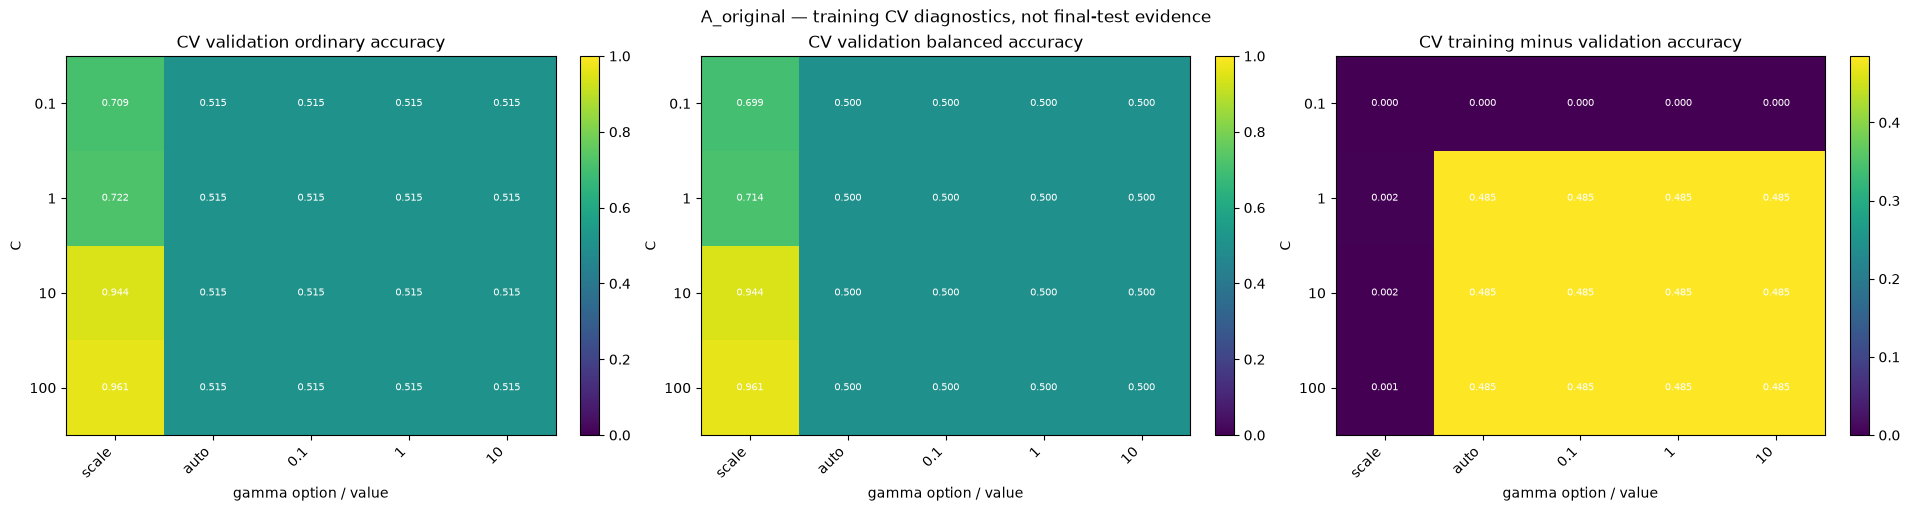
    



    
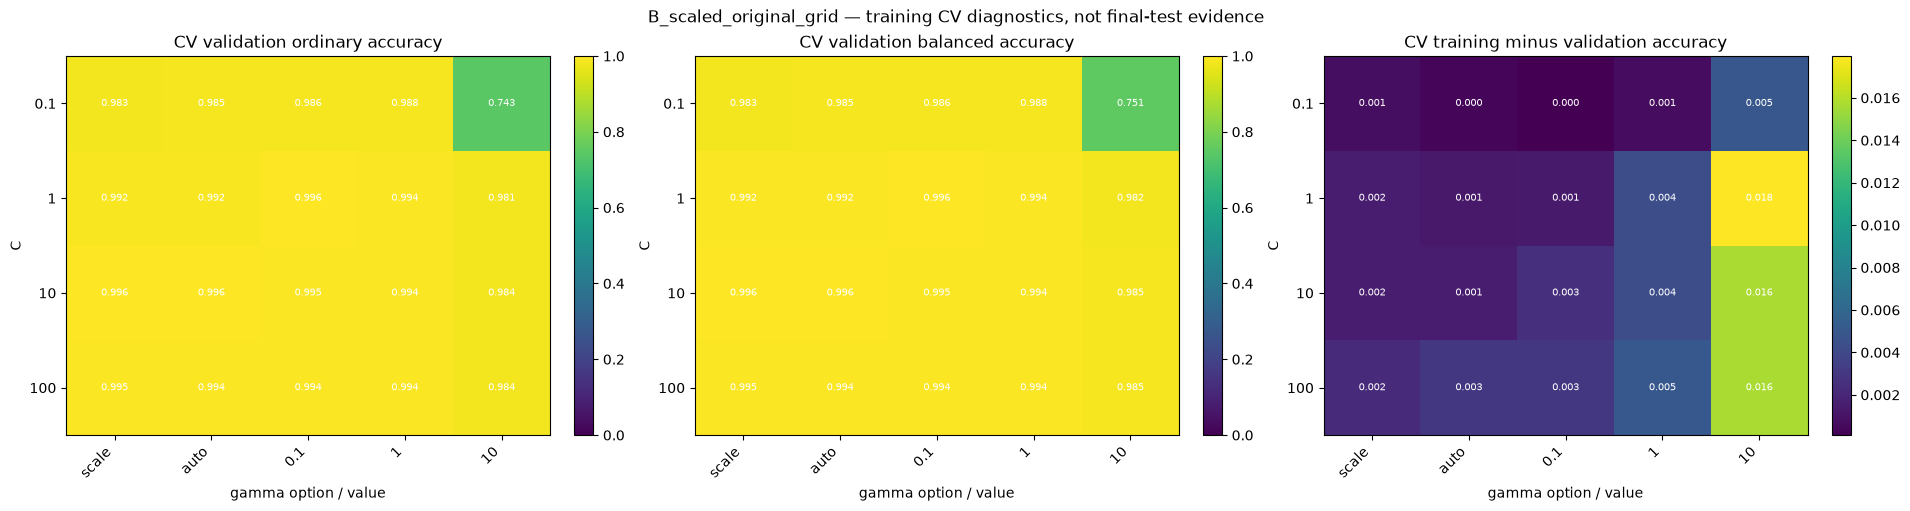
    



    
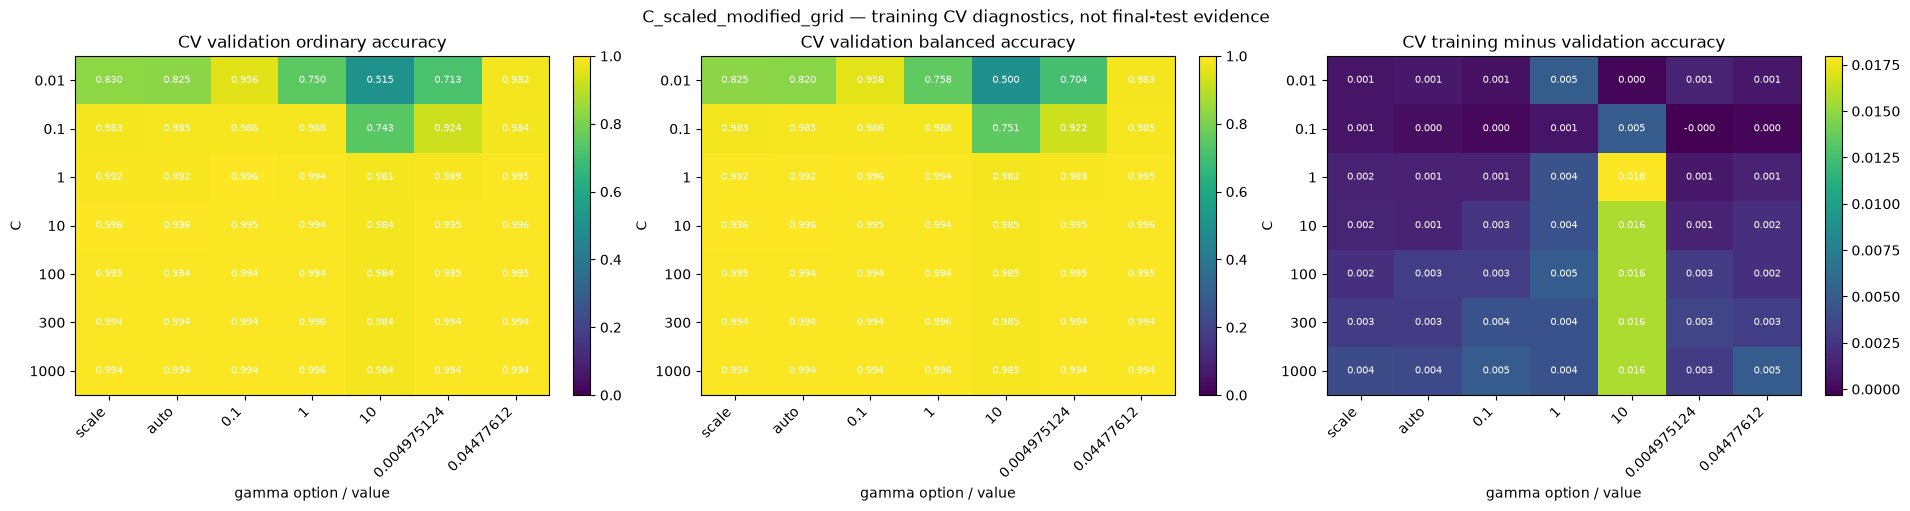
    



    
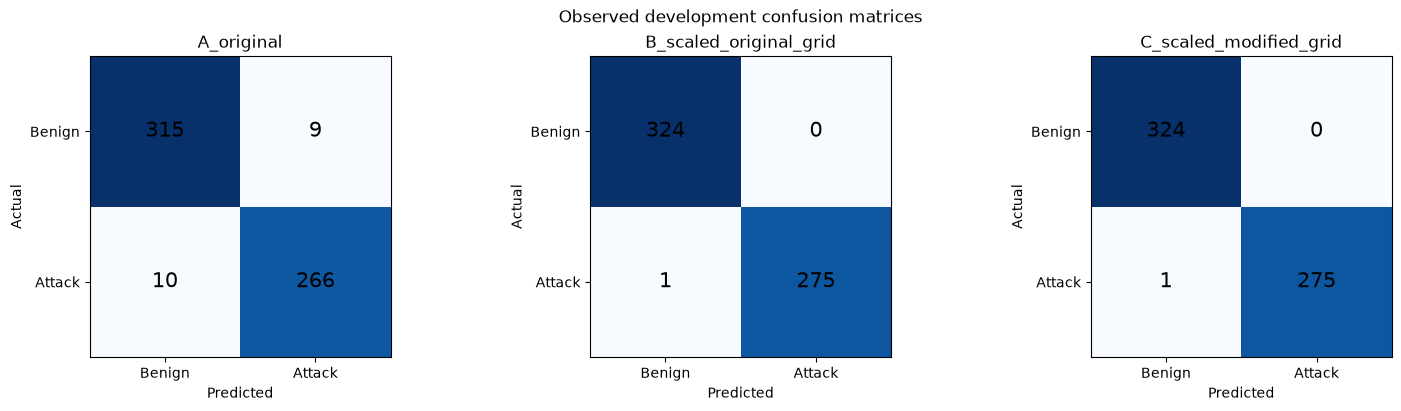
    




## 9. Final checks and evidence package
These checks validate bookkeeping and implementation when you run the notebook. They do not prove that network flows are independent, that the labels are perfect, or that the resulting model generalises beyond this day's filtered traffic.

No earlier Option B/C reserve feature/label arrays are loaded here. An optional protected row/group manifest is checked before any fitting. Before any final evaluation, establish a new frozen evaluation protocol and audit earlier exposure at row/group level. The already examined 600 rows are development data. Further confirmation on predefined seeds or group-aware splits needs a separate plan; never select a favourable seed.

JATI drafting begins after reviewing actual results, unresolved flaws and repeatability. Null/negative improvements are legitimate outcomes; the assignment requires justified parameter modification and systematic reporting, not a guaranteed accuracy target.




In [ ]:
# Verify the records and package the evidence.

validation_checks["split"] = {
    "sample_size": SAMPLE_SIZE,
    "training_rows": len(y_train),
    "development_rows": len(y_eval),
    "outer_row_disjoint": bool(not set(train_indices).intersection(evaluation_indices)),
    "validation_partition_checked": bool(np.all(validation_seen == 1)),
    "finite_features": bool(np.isfinite(X).all()),
    "label_one_means_attack": True,
    "all_searches_same_inputs_and_folds": True,
    "feature_policy_train_only": False,
    "feature_policy_note": "Source-compatible population-based column dropping retained and disclosed."
}
# Compile source cells from the saved notebook if it is available under this filename.
# This is a syntax check, not execution of those cells or a claim of model correctness.
if NOTEBOOK_PATH.is_file():
    notebook_document = json.loads(NOTEBOOK_PATH.read_text(encoding="utf-8"))
    compiled_count = 0
    for index, cell in enumerate(notebook_document["cells"]):
        if cell["cell_type"] == "code":
            compile("".join(cell["source"]), f"{NOTEBOOK_PATH.name}:cell_{index + 1}", "exec")
            compiled_count += 1
    validation_checks["notebook_python_syntax"] = {"checked": True, "code_cells": compiled_count}
else:
    validation_checks["notebook_python_syntax"] = {
        "checked": False,
        "reason": "Notebook file not accessible under NOTEBOOK_PATH; set it to the saved file and rerun this cell."
    }

save_json("validation_checks.json", validation_checks)
save_json("experiment_settings.json", {
    "source_url": SOURCE_URL,
    "sample_rows": SAMPLE_SIZE,
    "split_fraction": EVALUATION_FRACTION,
    "seed": SOURCE_SEED,
    "outer_stratified": False,
    "cv_folds": N_FOLDS,
    "cv_shuffle": False,
    "refit": "accuracy",
    "scoring_names": list(SCORING),
    "n_jobs": N_JOBS,
    "training_input_sha256": input_digest,
    "experiments_executed": list(searches),
    "tuning_executed": "C_scaled_modified_grid" in searches,
    "reference_baseline_matched": REFERENCE_MATCH,
    "separate_final_test_scored": False,
    "reserve_manifest_supplied": PROTECTED_RESERVE_PATH is not None,
    "measurement_status": "Generated by this user execution"
})
report_lines = [
    "# Controlled SVM experiment report",
    "",
    f"Run: {run_id}",
    "",
    "These are development results generated by notebook execution. No separate reserved final-test scores were computed; reserve row/group exposure is audited only when a manifest is supplied.",
    "The source-compatible population-wide feature-dropping rule and random row split remain inherited limitations.",
    "",
    "## Executed experiments",
    ""
]
for name, row in comparison.iterrows():
    report_lines.extend([
        f"### {name}", "",
        f"- Selected by mean CV ordinary accuracy: {row['best_parameters']}.",
        f"- CV ordinary accuracy: {row['cv_mean_test_accuracy']:.6%}; balanced accuracy: {row['cv_mean_test_balanced_accuracy']:.6%}.",
        f"- Development ordinary accuracy: {row['development_ordinary_accuracy']:.6%}; balanced accuracy: {row['development_balanced_accuracy']:.6%}.",
        f"- Missed attacks: {int(row['development_fn'])}; false alarms: {int(row['development_fp'])}; total errors: {int(row['development_errors'])}.",
        f"- Attack precision: {row['development_attack_precision']:.6%}; recall: {row['development_attack_recall']:.6%}; F1: {row['development_attack_f1']:.6%}.",
        f"- CV training minus validation ordinary accuracy: {row['cv_train_validation_accuracy_gap']:.6%}.",
        f"- Search plus refit time: {row['search_and_refit_seconds']:.3f} seconds.",
        ""
    ])
report_lines += ["## Paired changes", ""]
for row in pair_rows:
    report_lines += [
        f"- {row['from']} to {row['to']}: ordinary change {row['ordinary_accuracy_change_pp']:+.4f} percentage points; balanced change {row['balanced_accuracy_change_pp']:+.4f} percentage points; corrected errors {row['corrected_errors']}; introduced errors {row['introduced_errors']}.",
        ""
    ]
report_lines += [
    "## Limits and next decision", "",
    f"- Existing reserve manifest supplied: {reserve_guard['manifest_supplied']}; selected sample exposure verified: {reserve_guard['exposure_verified']}.",
    f"- Supplied baseline confusion matrix reproduced: {REFERENCE_MATCH}.",
    f"- Outer shared Flow IDs: {overlap_audit['outer_shared_flow_ids']}.",
    f"- Development rows whose exact feature vector appears in training: {overlap_audit['outer_evaluation_rows_with_training_feature_match']}.",
    f"- CV folds with shared Flow IDs: {overlap_audit['cv_folds_with_shared_flow_ids']}.",
    "- Any paired p-values are exploratory, unadjusted and depend on row independence.",
    "- CV means and development metrics are distinct; neither is untouched final-test evidence.",
    "- One favourable 600-row comparison is insufficient to establish robust generalisation.",
    "- Any boundary winner leaves the beyond-range optimum unresolved.",
    "- Check precision, recall, missed attacks and false alarms rather than describing every accuracy increase as an overall improvement.",
    "- A null result remains reportable. Do not invent a perfect model or promise 99.5%.",
    "- Propose a separate repetition/group-aware evaluation before final claims. Audit earlier exposure when defining the final reserve.",
    "- JATI writing remains a later phase.", ""
]
if "C_scaled_modified_grid" not in searches:
    report_lines += [
        "**C parameter experiment is pending. These files contain A/B results and the C proposal only.**",
        ""
    ]
(evidence_dir / "experiment_report.md").write_text("\n".join(report_lines), encoding="utf-8")
export_progress()

manifest = {
    path.name: sha256_file(path)
    for path in sorted(evidence_dir.iterdir())
    if path.is_file() and path.name != "manifest_sha256.json"
}
archive_path = OUTPUT_ROOT / f"{run_id}_evidence.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(evidence_dir.iterdir()):
        if path.is_file():
            archive.write(path, arcname=evidence_dir.name + "/" + path.name)
print("Saved evidence folder:", evidence_dir.resolve())
print("Shareable ZIP:", archive_path.resolve())
print("Experiments actually executed:", list(searches))
print("Save this executed .ipynb too; it is not automatically included in the ZIP.")


**Recorded output from the supplied run — not rerun here**

    Saved evidence folder: [local folder]/20261004T102021Z_45a6d3fc
    Shareable ZIP: [local folder]/20261004T102021Z_45a6d3fc_evidence.zip
    Experiments actually executed: ['A_original', 'B_scaled_original_grid', 'C_scaled_modified_grid']
    Save this executed .ipynb too; it is not automatically included in the ZIP.
    



## What changed inside the program?
- Replaced standalone SVC with `Pipeline(StandardScaler, SVC)` for B/C. A remains unscaled.
- Kept the original C/gamma grid for A/B, then added explicit new C/gamma values for C.
- Materialised the source's same CV folds once; retained accuracy as the refit criterion.
- Added multi-metric scoring and `return_train_score=True`; fixed CV plot metric names.
- Saved original CSV row IDs and metadata outside feature inputs, exact splits/folds, selected models, prediction rows, all CV results, timing, versions and checks.
- Replaced hardcoded plot/report values with observed predictions. ROC AUC and average precision are calculated separately from decision scores.
- Did not repeat the source's test-set C sweep as a tuning procedure.
- Replaced whole-file loading and large duplicated balanced dataframes with two-pass chunk loading and position-based sampling. This equivalence is checked indirectly by sample counts and baseline reproduction; the reconstruction has not been executed by the assistant.

**Evidence inspected before preparation:** the supplied screenshots of the executed baseline and earlier read-only reviews of `successful original source run.zip`, `Source Code SVM.zip`, the original GitHub notebook, assignment question and assignment guide. The original full CSV was inspected in earlier work; this new notebook's outputs are not yet inspected or verified. Prior experiment archives are not used as fabricated results for A/B/C.

**Remaining decisions:** inspect the generated audit and A/B results, run C, review whether metrics show a useful tradeoff, and define a separate robust confirmation protocol. Any local commands or training by the assistant require your permission.
